# 05 · Production monitoring simulation

We treat the **validation period** (Apr–Aug 2020) as the window where the model and threshold were signed off, and "go live" on **25 Aug 2020**. Each later month is scored as if it were production traffic. Each month we track:

| Signal | Needs labels? | Why it matters |
|---|---|---|
| Alert volume per day | No | Staffing: an alert flood is the first thing operations notices |
| Score PSI | No | Earliest sign that the population, or the model's view of it, has shifted |
| Feature PSI (key features) | No | Tells us *which* input moved; separates data issues from behaviour change |
| Missing-data rate | No | Pipeline or feature-store failures |
| Fraud rate | Yes | Changes the precision you can expect at a fixed threshold |
| Precision, recall | Yes | The real performance, but only once labels mature |

**Label delay.** Fraud labels come from chargebacks and customer disputes, which take weeks. We assume **60 days to label maturity**, so label-based metrics for the most recent two months are provisional. That's why the label-free signals are the early warning system.

In [1]:
import sys, pathlib, json, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display, Markdown

from src import config, drift, features, metrics, plotting
from src.plotting import takeaway

plotting.set_style()
pd.set_option("display.width", 220, "display.max_columns", 40, "display.float_format", "{:,.3f}".format)

bundle = joblib.load(config.MODELS_DIR / "models.joblib")
LGB, FRAME, CATS = bundle["lgbm"], bundle["lgbm_frame"], bundle["categories"]
scores = pd.read_parquet(config.DATA_PROCESSED / "scores.parquet")
decision = json.loads((config.REPORTS / "threshold_decision.json").read_text())
T = decision["thresholds"]["Cost-minimising"]
ref = scores[scores.split == "validation"].reset_index(drop=True)
live = scores[scores.split == "test"].reset_index(drop=True)
SCORE = "score_LightGBM"
KEY_FEATURES = ["log_amt", "hour", "n_txn_prior_24h", "amt_sum_prior_24h", "amt_to_cust_avg", "hours_since_last_txn",
                "dist_home_merchant_km", "is_first_merchant_for_cust", "category"]
LABEL_MATURITY_DAYS = 60
X_of = lambda d: features.onehot_frame(d, CATS) if FRAME == "onehot" else features.tree_frame(d, CATS)
print(f"Reference: {ref.ts.min():%Y-%m-%d} to {ref.ts.max():%Y-%m-%d} | Live: {live.ts.min():%Y-%m-%d} to {live.ts.max():%Y-%m-%d} | threshold {T:.4f}")

Reference: 2020-04-07 to 2020-08-24 | Live: 2020-08-25 to 2020-12-31 | threshold 0.0084


## 1. Alert triggers

These are defined **before** looking at the live months:

In [2]:
ref_perf = metrics.at_threshold(ref.is_fraud, ref[SCORE], ref.amt, T, metrics.n_days(ref.ts))
TRIGGERS = {
    "psi_score": 0.20,          # score distribution shift
    "psi_feature": 0.20,        # any key feature
    "precision_min": 0.40,      # below 40% the queue is mostly noise (validation value printed below)
    "recall_min": 0.90,         # below 90% we are missing materially more fraud
    "capacity": config.DAILY_REVIEW_CAPACITY,
    "missing_pct": 2.0,         # share of rows with any missing model input (reference level printed below)
}
trig_table = pd.DataFrame([
    ("Score PSI", "> 0.20", "No", "Investigate population/model shift; check feature PSI to localise"),
    ("Any key-feature PSI", "> 0.20", "No", "Check the data pipeline first, then behaviour change; review the threshold"),
    ("Precision at threshold", f"< {TRIGGERS['precision_min']:.0%}  (validation {ref_perf['precision']:.0%})", "Yes (60-day lag)", "Re-tune the threshold on recent matured data"),
    ("Recall at threshold", f"< {TRIGGERS['recall_min']:.0%}  (validation {ref_perf['recall']:.0%})", "Yes (60-day lag)", "Investigate new fraud patterns; lower the threshold as an interim measure; retrain"),
    ("Alerts per day", f"> {TRIGGERS['capacity']} (capacity)", "No", "Raise the threshold temporarily; add staff; investigate cause"),
    ("Missing-input rate", f"> {TRIGGERS['missing_pct']}%", "No", "Incident: feature-store/pipeline check; fall back to rules if needed"),
], columns=["signal", "trigger", "needs labels?", "action"])
trig_table.loc[len(trig_table)] = ["Score-tail PSI (top 10% of scores)", "> 0.20", "No", "Changes among the scores that generate alerts; standard PSI cannot see these"]
trig_table.to_csv(config.REPORTS / "monitoring_triggers.csv", index=False)
print(f"Reference missing-input rate: {100 * ref[features.NUMERIC_FEATURES].isna().any(axis=1).mean():.3f}% of rows")
trig_table

Reference missing-input rate: 0.037% of rows


,signal,trigger,needs labels?,action
0,Score PSI,> 0.20,No,Investigate population/model shift; check feat...
1,Any key-feature PSI,> 0.20,No,"Check the data pipeline first, then behaviour ..."
2,Precision at threshold,< 40% (validation 63%),Yes (60-day lag),Re-tune the threshold on recent matured data
3,Recall at threshold,< 90% (validation 98%),Yes (60-day lag),Investigate new fraud patterns; lower the thre...
4,Alerts per day,> 100 (capacity),No,Raise the threshold temporarily; add staff; in...
5,Missing-input rate,> 2.0%,No,Incident: feature-store/pipeline check; fall b...
6,Score-tail PSI (top 10% of scores),> 0.20,No,Changes among the scores that generate alerts;...


## 2. Monthly monitoring of the live period

In [3]:
both = pd.concat([ref.assign(window="reference"), live.assign(window="live")], ignore_index=True)
mon = drift.monthly_monitoring(both, ref, SCORE, T, KEY_FEATURES)
mon["window"] = np.where(pd.PeriodIndex(mon.period, freq="M").to_timestamp() < live.ts.min().normalize().replace(day=1), "reference", "live")
# Aug 2020 straddles go-live; split it so reference and live months are not mixed
aug = pd.Period(live.ts.min(), freq="M")
mon.loc[mon.period == str(aug), "window"] = "mixed (go-live month)"
as_of = live.ts.max().normalize()
mon["labels_mature"] = [(as_of - pd.Period(p, freq="M").end_time.normalize()).days >= LABEL_MATURITY_DAYS for p in mon.period]
mon.to_csv(config.REPORTS / "monitoring_monthly.csv", index=False)
mon.to_csv(config.DASHBOARD_DATA / "monitoring_monthly.csv", index=False)
cols = ["period", "window", "transactions", "fraud_rate_pct", "alerts_per_day", "precision", "recall", "psi_score", "psi_score_tail", "missing_rate_pct", "labels_mature"]
mon[cols]

,period,window,transactions,fraud_rate_pct,alerts_per_day,precision,recall,psi_score,psi_score_tail,missing_rate_pct,labels_mature
0,2020-04,reference,53895,0.481,18.792,0.559,0.973,0.005,0.001,0.009,True
1,2020-05,reference,74343,0.709,24.484,0.690,0.994,0.002,0.001,0.009,True
2,2020-06,reference,87805,0.532,24.067,0.630,0.974,0.000,0.000,0.003,True
3,2020-07,reference,85848,0.374,17.548,0.574,0.972,0.001,0.001,0.003,True
4,2020-08,mixed (go-live month),88759,0.468,20.419,0.646,0.986,0.002,0.000,0.000,True
5,2020-09,live,69533,0.489,16.900,0.649,0.968,0.009,0.002,0.009,True
6,2020-10,live,69348,0.554,17.806,0.679,0.977,0.012,0.001,0.006,True
7,2020-11,live,72635,0.405,15.633,0.612,0.976,0.016,0.003,0.000,False
8,2020-12,live,139538,0.185,18.194,0.445,0.973,0.054,0.009,0.001,False


In [4]:
live_mon = mon[mon.window != "reference"]
fired = drift.evaluate_triggers(live_mon, TRIGGERS)
fired["labels_mature"] = fired.period.map(dict(zip(mon.period, mon.labels_mature)))
fired.to_csv(config.REPORTS / "monitoring_triggers_fired.csv", index=False)
fired.to_csv(config.DASHBOARD_DATA / "monitoring_triggers_fired.csv", index=False)
fired if len(fired) else Markdown("**No triggers fired in the live period.**")

,period,trigger,detail,labels_mature
0,2020-12,Any feature PSI > 0.2,"n_txn_prior_24h, amt_sum_prior_24h",False


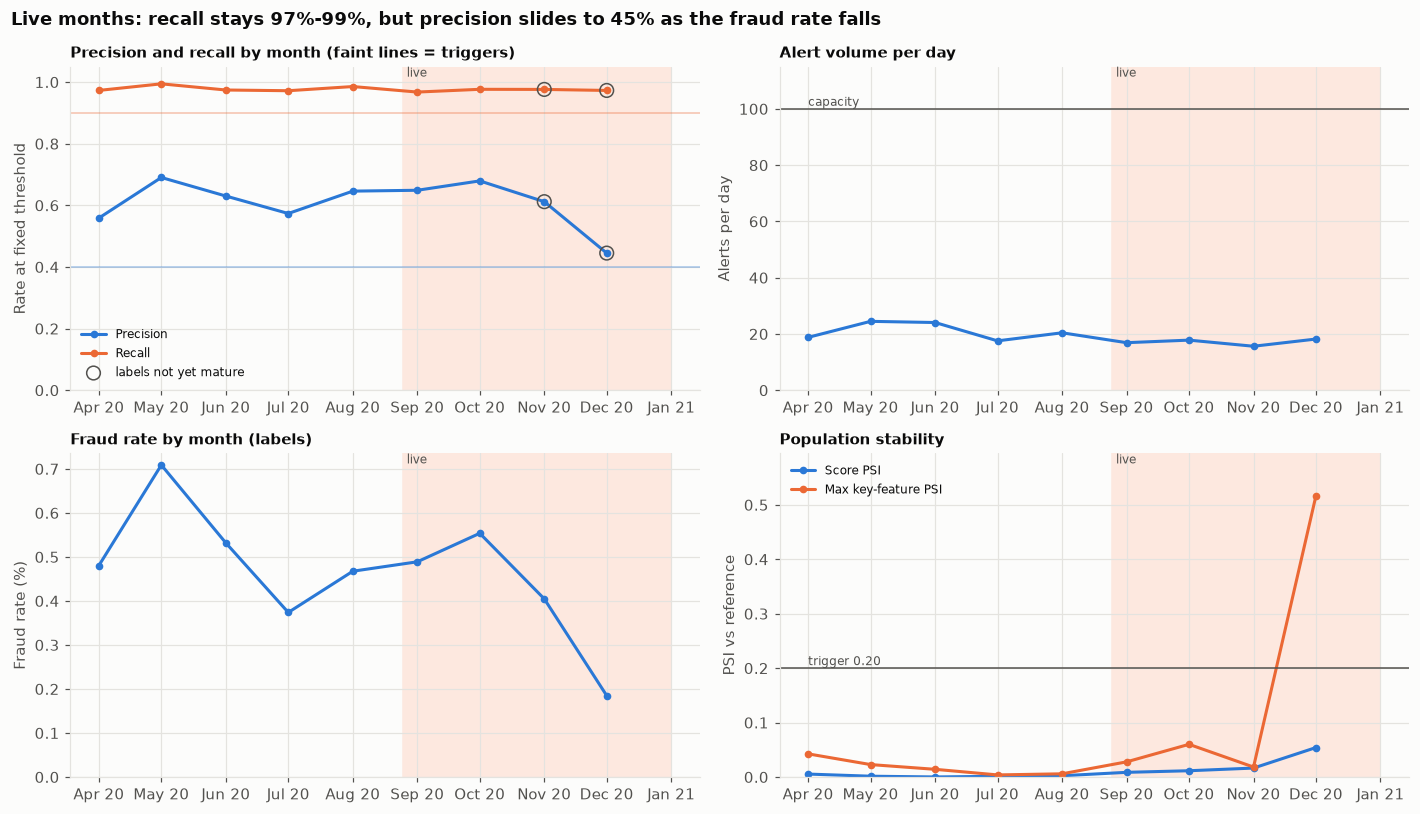

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
x = pd.PeriodIndex(mon.period, freq="M").to_timestamp()
live_start = live.ts.min()
def shade(ax):
    ax.axvspan(live_start, x.max() + pd.Timedelta(days=31), color="#fde8df", zorder=0)
    ax.text(live_start, 1.0, " live", transform=ax.get_xaxis_transform(), color=plotting.TEXT_2, fontsize=8, va="top")
ax = axes[0, 0]; shade(ax)
ax.plot(x, mon.precision, marker="o", ms=4, color=plotting.BLUE, label="Precision")
ax.plot(x, mon.recall, marker="o", ms=4, color=plotting.ORANGE, label="Recall")
ax.axhline(TRIGGERS["precision_min"], color=plotting.BLUE, lw=1, ls=(0, (1, 0)), alpha=0.4)
ax.axhline(TRIGGERS["recall_min"], color=plotting.ORANGE, lw=1, alpha=0.4)
imm = ~mon.labels_mature.to_numpy()
ax.scatter(x[imm], mon.recall[imm], s=80, facecolor="none", edgecolor=plotting.TEXT_2, zorder=5, label="labels not yet mature")
ax.scatter(x[imm], mon.precision[imm], s=80, facecolor="none", edgecolor=plotting.TEXT_2, zorder=5)
ax.set_ylim(0, 1.05); ax.set_ylabel("Rate at fixed threshold"); ax.legend(fontsize=8, loc="lower left")
ax.set_title("Precision and recall by month (faint lines = triggers)", loc="left", fontsize=10)
ax = axes[0, 1]; shade(ax)
ax.plot(x, mon.alerts_per_day, marker="o", ms=4, color=plotting.BLUE)
ax.axhline(config.DAILY_REVIEW_CAPACITY, color=plotting.TEXT_2, lw=1); ax.text(x.min(), config.DAILY_REVIEW_CAPACITY, "capacity", fontsize=8, va="bottom", color=plotting.TEXT_2)
ax.set_ylim(0, config.DAILY_REVIEW_CAPACITY * 1.15); ax.set_ylabel("Alerts per day")
ax.set_title("Alert volume per day", loc="left", fontsize=10)
ax = axes[1, 0]; shade(ax)
ax.plot(x, mon.fraud_rate_pct, marker="o", ms=4, color=plotting.BLUE)
ax.set_ylabel("Fraud rate (%)"); ax.set_ylim(0, None)
ax.set_title("Fraud rate by month (labels)", loc="left", fontsize=10)
ax = axes[1, 1]; shade(ax)
ax.plot(x, mon.psi_score, marker="o", ms=4, color=plotting.BLUE, label="Score PSI")
ax.plot(x, mon[[f"psi_{f}" for f in KEY_FEATURES]].max(axis=1), marker="o", ms=4, color=plotting.ORANGE, label="Max key-feature PSI")
ax.axhline(0.2, color=plotting.TEXT_2, lw=1); ax.text(x.min(), 0.2, "trigger 0.20", fontsize=8, va="bottom", color=plotting.TEXT_2)
ax.set_ylabel("PSI vs reference"); ax.set_ylim(0, max(0.3, mon[["psi_score"] + [f"psi_{f}" for f in KEY_FEATURES]].max().max() * 1.15)); ax.legend(fontsize=8, loc="upper left")
ax.set_title("Population stability", loc="left", fontsize=10)
import matplotlib.dates as mdates
for a in axes.flat:
    a.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
lm = live_mon
fig.suptitle(f"Live months: recall stays {lm.recall.min():.0%}-{lm.recall.max():.0%}, but precision slides to {lm.precision.min():.0%} as the fraud rate falls",
             x=0.01, ha="left", fontweight="bold")
plotting.save(fig, "monitoring_dashboard"); plt.show()

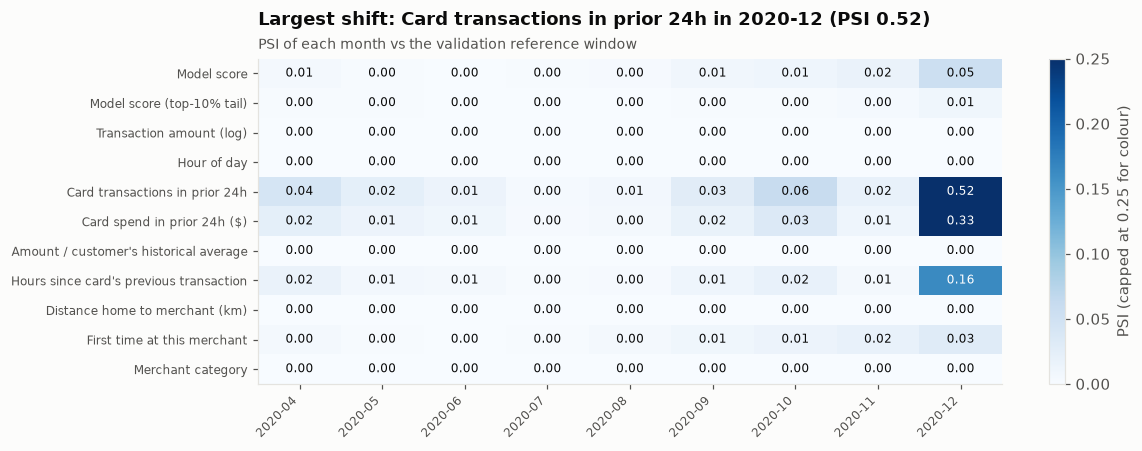

In [6]:
psi_cols = [f"psi_{f}" for f in KEY_FEATURES]
heat = mon.set_index("period")[["psi_score", "psi_score_tail"] + psi_cols].T
fig, ax = plt.subplots(figsize=(11, 4.2))
im = ax.imshow(heat.values, cmap="Blues", vmin=0, vmax=0.25, aspect="auto")
for (i, j), v in np.ndenumerate(heat.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.15 else plotting.TEXT)
ax.set_xticks(range(heat.shape[1]), heat.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(heat.shape[0]), ["Model score", "Model score (top-10% tail)"] + [features.FEATURE_LABELS.get(f, f) for f in KEY_FEATURES], fontsize=8)
ax.grid(False); fig.colorbar(im, ax=ax, label="PSI (capped at 0.25 for colour)")
worst_cell = heat.stack().idxmax()
plotting.title(ax, f"Largest shift: {features.FEATURE_LABELS.get(worst_cell[0].replace('psi_', ''), worst_cell[0].replace('psi_', ''))} in {worst_cell[1]} (PSI {heat.stack().max():.2f})",
               "PSI of each month vs the validation reference window")
plotting.save(fig, "psi_heatmap"); plt.show()

In [7]:
dec = mon.iloc[-1]
takeaway(f"In {dec.period} the score PSI is {dec.psi_score:.2f} (tail PSI {dec.psi_score_tail:.2f}) and the largest feature PSI is {dec[psi_cols].max():.2f} "
         f"({dec[psi_cols].astype(float).idxmax().replace('psi_', '')}), while alerts/day stay at {dec.alerts_per_day:.1f}, far below capacity. "
         "Holiday volume doubles transactions per card, which explains the velocity-feature shift. "
         f"The lower precision is consistent with the lower fraud rate ({dec.fraud_rate_pct:.2f}%), a base-rate effect. **This is provisional**: "
         "December labels are not mature, so the 'no retrain needed' conclusion should be confirmed once they are (and ideally checked against a "
         "seasonal reference such as the previous December).")

**Takeaway:** In 2020-12 the score PSI is 0.05 (tail PSI 0.01) and the largest feature PSI is 0.52 (n_txn_prior_24h), while alerts/day stay at 18.2, far below capacity. Holiday volume doubles transactions per card, which explains the velocity-feature shift. The lower precision is consistent with the lower fraud rate (0.18%), a base-rate effect. **This is provisional**: December labels are not mature, so the 'no retrain needed' conclusion should be confirmed once they are (and ideally checked against a seasonal reference such as the previous December).

## 3. Weekly view: what operations would see first

In [8]:
weekly = drift.monthly_monitoring(live, ref, SCORE, T, ["log_amt", "hour", "amt_to_cust_avg"], period="W")
weekly.to_csv(config.DASHBOARD_DATA / "monitoring_weekly.csv", index=False)
weekly[["period", "transactions", "alerts_per_day", "precision", "recall", "psi_score", "missing_rate_pct"]]

,period,transactions,alerts_per_day,precision,recall,psi_score,missing_rate_pct
0,2020-08-24/2020-08-30,15564,20.500,0.626,0.987,0.001,0.000
1,2020-08-31/2020-09-06,17681,20.000,0.614,1.000,0.002,0.017
2,2020-09-07/2020-09-13,16268,15.286,0.664,0.986,0.010,0.000
3,2020-09-14/2020-09-20,16008,13.143,0.543,0.943,0.012,0.000
4,2020-09-21/2020-09-27,15922,19.000,0.729,0.942,0.013,0.013
5,2020-09-28/2020-10-04,16018,18.857,0.712,0.979,0.022,0.012
6,2020-10-05/2020-10-11,15928,19.571,0.701,0.960,0.016,0.000
7,2020-10-12/2020-10-18,15972,21.571,0.755,0.983,0.017,0.000
8,2020-10-19/2020-10-25,15888,14.857,0.625,1.000,0.006,0.013
9,2020-10-26/2020-11-01,15993,14.714,0.495,0.962,0.009,0.006


## 4. Stress tests: would the monitoring catch real problems?

The live data happens to be fairly stable, so we inject two realistic failures into **copies** of the December data. Each copy is re-scored with the production model. These are clearly labelled **simulations**, used to test the monitoring design itself.

**A. Adversarial adaptation.** Fraudsters notice night-time transactions get blocked and move to daytime. We shift every December fraud's timestamp by 12 hours: `hour` and `is_night` change, and nothing else does.

**B. Pipeline failure.** For one week, the feature store fails to return customer-history features (`amt_to_cust_avg`, `amt_zscore_cust`, `hours_since_last_txn`) for 30% of transactions.

In [9]:
dec = live[live.ts.dt.to_period("M") == live.ts.max().to_period("M")].copy()
base_perf = metrics.at_threshold(dec.is_fraud, dec[SCORE], dec.amt, T, metrics.n_days(dec.ts))

# A. adversarial shift to daytime
adv = dec.copy()
f_mask = adv.is_fraud == 1
adv.loc[f_mask, "hour"] = (adv.loc[f_mask, "hour"] + 12) % 24
adv.loc[f_mask, "is_night"] = ((adv.loc[f_mask, "hour"] >= 22) | (adv.loc[f_mask, "hour"] < 4)).astype(adv["is_night"].dtype)
adv[SCORE] = LGB.predict_proba(X_of(adv))[:, 1]
adv_perf = metrics.at_threshold(adv.is_fraud, adv[SCORE], adv.amt, T, metrics.n_days(adv.ts))

# B. pipeline failure for one week
pipe = dec.copy()
rng = np.random.default_rng(config.SEED)
wk = pipe.ts < pipe.ts.min() + pd.Timedelta(days=7)
hit = wk & (rng.random(len(pipe)) < 0.30)
for f in ["amt_to_cust_avg", "amt_zscore_cust", "hours_since_last_txn"]:
    pipe.loc[hit, f] = np.nan
pipe[SCORE] = LGB.predict_proba(X_of(pipe))[:, 1]
pipe_week = pipe[wk]
pipe_perf = metrics.at_threshold(pipe_week.is_fraud, pipe_week[SCORE], pipe_week.amt, T, metrics.n_days(pipe_week.ts))
dec_week = dec[wk]
base_week = metrics.at_threshold(dec_week.is_fraud, dec_week[SCORE], dec_week.amt, T, metrics.n_days(dec_week.ts))

def signals(d, perf):
    return {"alerts_per_day": perf["alerts_per_day"], "precision": perf["precision"], "recall": perf["recall"],
            "psi_score": drift.psi(ref[SCORE], d[SCORE]), "psi_hour": drift.psi(ref["hour"], d["hour"]),
            "psi_amt_to_cust_avg": drift.psi(ref["amt_to_cust_avg"], d["amt_to_cust_avg"]),
            "missing_rate_pct": 100 * d[features.NUMERIC_FEATURES].isna().any(axis=1).mean()}
stress = pd.DataFrame({
    "December as observed": signals(dec, base_perf),
    "A. Fraud shifts to daytime": signals(adv, adv_perf),
    "Week 1 as observed": signals(dec_week, base_week),
    "B. Feature-store outage (week 1)": signals(pipe_week, pipe_perf),
}).T
stress.to_csv(config.REPORTS / "monitoring_stress_tests.csv")
stress.to_csv(config.DASHBOARD_DATA / "monitoring_stress_tests.csv")
stress

,alerts_per_day,precision,recall,psi_score,psi_hour,psi_amt_to_cust_avg,missing_rate_pct
December as observed,18.194,0.445,0.973,0.054,0.000,0.000,0.008
A. Fraud shifts to daytime,17.419,0.420,0.880,0.054,0.000,0.000,0.008
Week 1 as observed,18.625,0.537,0.976,0.039,0.000,0.000,0.019
B. Feature-store outage (week 1),28.125,0.356,0.976,0.045,0.000,2.500,29.925


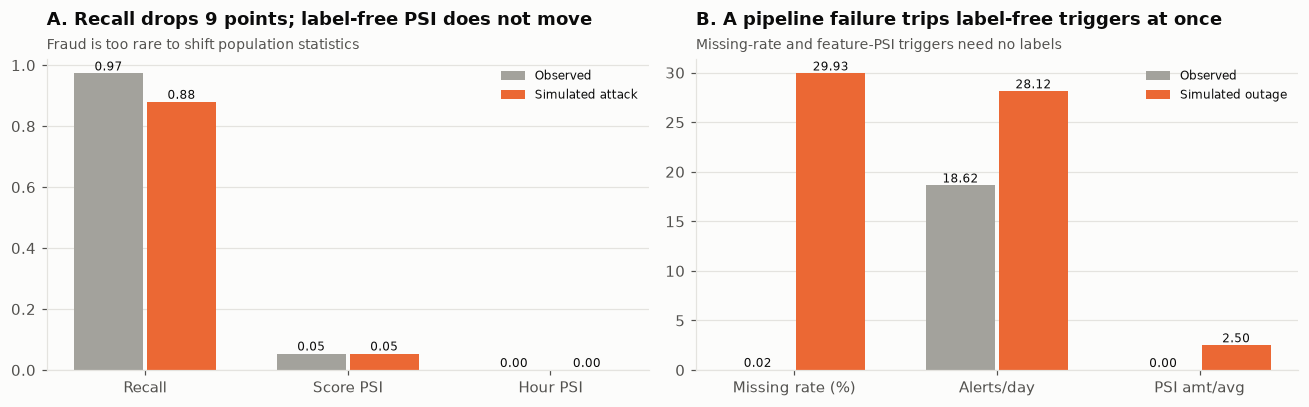

In [10]:
s = stress
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
lab = ["Recall", "Score PSI", "Hour PSI"]
v0 = [s.loc["December as observed", "recall"], s.loc["December as observed", "psi_score"], s.loc["December as observed", "psi_hour"]]
v1 = [s.loc["A. Fraud shifts to daytime", "recall"], s.loc["A. Fraud shifts to daytime", "psi_score"], s.loc["A. Fraud shifts to daytime", "psi_hour"]]
xx = np.arange(3)
ax.bar(xx - 0.18, v0, 0.34, color=plotting.NEUTRAL, label="Observed")
ax.bar(xx + 0.18, v1, 0.34, color=plotting.ORANGE, label="Simulated attack")
for i, (a, b) in enumerate(zip(v0, v1)):
    ax.text(i - 0.18, a, f"{a:.2f}", ha="center", va="bottom", fontsize=8); ax.text(i + 0.18, b, f"{b:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(xx, lab); ax.grid(axis="x", visible=False); ax.legend(fontsize=8)
plotting.title(ax, f"A. Recall drops {100 * (v0[0] - v1[0]):.0f} points; label-free PSI does not move", "Fraud is too rare to shift population statistics")
ax = axes[1]
lab = ["Missing rate (%)", "Alerts/day", "PSI amt/avg"]
w0 = [s.loc["Week 1 as observed", "missing_rate_pct"], s.loc["Week 1 as observed", "alerts_per_day"], s.loc["Week 1 as observed", "psi_amt_to_cust_avg"]]
w1 = [s.loc["B. Feature-store outage (week 1)", "missing_rate_pct"], s.loc["B. Feature-store outage (week 1)", "alerts_per_day"], s.loc["B. Feature-store outage (week 1)", "psi_amt_to_cust_avg"]]
ax.bar(xx - 0.18, w0, 0.34, color=plotting.NEUTRAL, label="Observed")
ax.bar(xx + 0.18, w1, 0.34, color=plotting.ORANGE, label="Simulated outage")
for i, (a, b) in enumerate(zip(w0, w1)):
    ax.text(i - 0.18, a, f"{a:.2f}", ha="center", va="bottom", fontsize=8); ax.text(i + 0.18, b, f"{b:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(xx, lab); ax.grid(axis="x", visible=False); ax.legend(fontsize=8)
plotting.title(ax, "B. A pipeline failure trips label-free triggers at once", "Missing-rate and feature-PSI triggers need no labels")
plotting.save(fig, "monitoring_stress_tests"); plt.show()

In [11]:
a, o = s.loc["A. Fraud shifts to daytime"], s.loc["December as observed"]
b, w = s.loc["B. Feature-store outage (week 1)"], s.loc["Week 1 as observed"]
takeaway(f"Simulation A: recall drops from {o.recall:.0%} to {a.recall:.0%}, yet score PSI moves only from {o.psi_score:.3f} to {a.psi_score:.3f}. "
         f"New fraud patterns are invisible to population-level drift metrics, and with a 60-day label lag they surface late. That is why the plan adds "
         "fast partial labels (customer-reported fraud, confirmed analyst dispositions) and a small random sample of below-threshold transactions for review. "
         f"Simulation B: the missing-input rate jumps from {w.missing_rate_pct:.1f}% to {b.missing_rate_pct:.1f}%, which would trip the daily missing-data trigger on the first day. "
         f"Alerts rise from {w.alerts_per_day:.1f} to {b.alerts_per_day:.1f}/day and precision falls from {w.precision:.0%} to {b.precision:.0%}: the model treats 'no history' as risky, "
         "so a pipeline outage floods the queue with false alerts rather than hiding fraud.")

**Takeaway:** Simulation A: recall drops from 97% to 88%, yet score PSI moves only from 0.054 to 0.054. New fraud patterns are invisible to population-level drift metrics, and with a 60-day label lag they surface late. That is why the plan adds fast partial labels (customer-reported fraud, confirmed analyst dispositions) and a small random sample of below-threshold transactions for review. Simulation B: the missing-input rate jumps from 0.0% to 29.9%, which would trip the daily missing-data trigger on the first day. Alerts rise from 18.6 to 28.1/day and precision falls from 54% to 36%: the model treats 'no history' as risky, so a pipeline outage floods the queue with false alerts rather than hiding fraud.

## 5. Realism checks: how much of the performance comes from the simulator?

Sparkov generates fraud from a few scripted patterns. Two checks show how the model would behave when reality is less tidy.

**A. Fraud that does not fit the dominant pattern.** The EDA showed that most fraud happens at night *and* for $250 or more. We split the test frauds into *on-pattern* (night and at least $250) and *off-pattern* (everything else), then measure each group separately against all legitimate transactions.

In [12]:
from sklearn.metrics import average_precision_score
on = (live.is_night == 1) & (live.amt >= 250)
legit = live.is_fraud == 0
rows = []
for name, fmask in [("On-pattern (night & >= $250)", on & (live.is_fraud == 1)), ("Off-pattern (day or < $250)", ~on & (live.is_fraud == 1))]:
    sub = live[legit | fmask]
    alert = live.loc[fmask, SCORE] >= T
    rows.append({"fraud group": name, "frauds": int(fmask.sum()), "share_of_fraud": fmask.sum() / live.is_fraud.sum(),
                 "fraud_usd": live.loc[fmask, "amt"].sum(), "recall_at_threshold": alert.mean(),
                 "pr_auc_vs_all_legit": average_precision_score(sub.is_fraud, sub[SCORE])})
pattern = pd.DataFrame(rows)
pattern.to_csv(config.REPORTS / "realism_off_pattern_fraud.csv", index=False)
pattern

,fraud group,frauds,share_of_fraud,fraud_usd,recall_at_threshold,pr_auc_vs_all_legit
0,On-pattern (night & >= $250),855,0.630,"604,043.460",0.994,0.989
1,Off-pattern (day or < $250),503,0.370,"134,011.600",0.940,0.890


In [13]:
p_on, p_off = pattern.iloc[0], pattern.iloc[1]
takeaway(f"{p_on.share_of_fraud:.0%} of test fraud follows the dominant simulator pattern, and the model catches {p_on.recall_at_threshold:.0%} of it. "
         f"On the other {p_off.share_of_fraud:.0%} of fraud (n={p_off.frauds:,}), recall is {p_off.recall_at_threshold:.0%} and PR-AUC {p_off.pr_auc_vs_all_legit:.3f}. "
         "Real fraud is mostly 'off-pattern' and adaptive, so a realistic expectation sits well below the headline.")

**Takeaway:** 63% of test fraud follows the dominant simulator pattern, and the model catches 99% of it. On the other 37% of fraud (n=503), recall is 94% and PR-AUC 0.890. Real fraud is mostly 'off-pattern' and adaptive, so a realistic expectation sits well below the headline.

**B. Unreported fraud (label noise).** In practice some fraud is never reported or charged back, so it enters training labelled as legitimate. We retrain with 20% and 40% of fraud-affected **cards** relabelled as legitimate. Whole episodes go unreported, not single transactions. The noise is applied to both train and validation, because both would be affected, and the model is scored on **true** test labels. For speed, the experiment uses the undersampled LightGBM variant (4x faster to train, within 0.005 PR-AUC of the chosen model).

In [14]:
from src import data, models
full = features.add_derived(data.load_features()).merge(pd.read_parquet(config.DATA_PROCESSED / "splits.parquet"), on="trans_num")
tr_f, va_f, te_f = (full[full.split == s].reset_index(drop=True) for s in ["train", "validation", "test"])
Xt = {k: features.tree_frame(d, CATS) for k, d in [("tr", tr_f), ("va", va_f), ("te", te_f)]}
noise_rows = []
for noise in [0.0, 0.2, 0.4]:
    r = np.random.default_rng(config.SEED)
    y_tr, y_va = tr_f.is_fraud.copy(), va_f.is_fraud.copy()
    for d, y in [(tr_f, y_tr), (va_f, y_va)]:
        fraud_cards = d.loc[d.is_fraud == 1, "cc_num"].unique()
        hidden = r.choice(fraud_cards, int(noise * len(fraud_cards)), replace=False)
        y[d.cc_num.isin(hidden) & (d.is_fraud == 1)] = 0
    Xr, yr = models.resample(Xt["tr"], y_tr, "undersample")
    m = models.fit_lgbm(Xr, yr, Xt["va"], y_va)
    s_te = m.predict_proba(Xt["te"])[:, 1]
    noise_rows.append({"unreported_fraud_cards": f"{noise:.0%}", "train_frauds_labelled": int(y_tr.sum()),
                       "test_pr_auc_true_labels": metrics.pr_auc(te_f.is_fraud, s_te)})
noise_tbl = pd.DataFrame(noise_rows)
noise_tbl.to_csv(config.REPORTS / "realism_label_noise.csv", index=False)
noise_tbl

,unreported_fraud_cards,train_frauds_labelled,test_pr_auc_true_labels
0,0%,6386,0.965
1,20%,5130,0.950
2,40%,3803,0.919


In [15]:
n0, n40 = noise_tbl.iloc[0], noise_tbl.iloc[-1]
takeaway(f"Hiding 40% of fraud episodes from training moves test PR-AUC from {n0.test_pr_auc_true_labels:.3f} to {n40.test_pr_auc_true_labels:.3f}. "
         "Tree models are fairly robust to *random* missing labels when the fraud signal is this strong. In real portfolios, unreported fraud is not random "
         "(e.g. small amounts customers don't notice), which biases the model against exactly those cases. Fast, unbiased label capture belongs in the monitoring plan.")

**Takeaway:** Hiding 40% of fraud episodes from training moves test PR-AUC from 0.965 to 0.919. Tree models are fairly robust to *random* missing labels when the fraud signal is this strong. In real portfolios, unreported fraud is not random (e.g. small amounts customers don't notice), which biases the model against exactly those cases. Fast, unbiased label capture belongs in the monitoring plan.

## 6. Monitoring and recalibration plan

| Cadence | Activity | Owner |
|---|---|---|
| **Daily** | Alert volume vs capacity; missing-input rate; score-distribution sanity check (automated, alerts on breach) | Fraud ops / data engineering |
| **Weekly** | Score and key-feature PSI; analyst disposition rate on worked alerts (a fast, partial precision signal); fraud reported by customers that the model scored below threshold | Fraud analytics |
| **Monthly** | Precision and recall on **matured** labels (60+ days old); segment error review; threshold check. **Recalibrate the threshold** if the cost-optimal point on the latest matured 3 months moves by more than ±25% in alerts/day | Fraud analytics + fraud ops lead |
| **Quarterly** | Retrain on a rolling window (latest 12–15 months, with the most recent matured months as validation); champion/challenger comparison on the same period; fairness/segment review; model-risk sign-off | Data science + model risk |
| **On trigger** | Recall trigger or confirmed new pattern: add a targeted rule immediately (hours), then retrain (weeks). PSI/missing trigger: check the data pipeline first | As above |

**Threshold recalibration protocol.** Re-run notebook 03 on the latest matured 3 months, keeping the same cost assumptions. Change the threshold only if the new optimum lies outside the flat region of the cost curve, because small moves inside it are noise. Log every change with date, reason and expected alert volume.

**Feedback-loop guard.** Labels only exist for what was reviewed or disputed. To keep a view of missed fraud:
- review the **monitor-only band** with the team's spare capacity (sized in notebook 06). A small random sample far below the threshold would find almost no fraud.
- track customer-reported fraud that the model scored low.

In [16]:
summary = {
    "live_months": live_mon.period.tolist(),
    "triggers_fired": fired.to_dict("records"),
    "live_precision_range": [float(live_mon.precision.min()), float(live_mon.precision.max())],
    "live_recall_range": [float(live_mon.recall.min()), float(live_mon.recall.max())],
    "max_live_score_psi": float(live_mon.psi_score.max()),
}
(config.REPORTS / "monitoring_summary.json").write_text(json.dumps(summary, indent=2, default=str))
summary

{'live_months': ['2020-08', '2020-09', '2020-10', '2020-11', '2020-12'],
 'triggers_fired': [{'period': '2020-12',
   'trigger': 'Any feature PSI > 0.2',
   'detail': 'n_txn_prior_24h, amt_sum_prior_24h',
   'labels_mature': False}],
 'live_precision_range': [0.4450354609929078, 0.6793478260869565],
 'live_recall_range': [0.9676470588235294, 0.9855421686746988],
 'max_live_score_psi': 0.05415531233826013}